Normal MZI (π phase): {'1': 1000}
Which path MZI: {'10': 232, '01': 261, '00': 236, '11': 271}


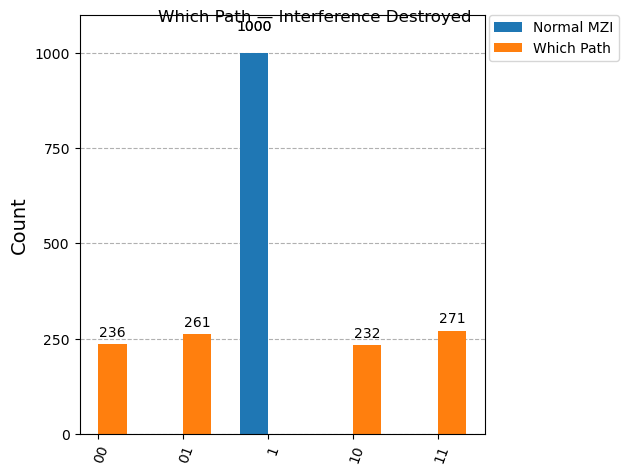

In [1]:
# 03_mzi_which_path.ipynb
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np

simulator = AerSimulator()

# --- Circuit A: Normal MZI — interference present ---
qcA = QuantumCircuit(1, 1)
qcA.h(0)
qcA.rz(np.pi, 0)
qcA.h(0)
qcA.measure(0, 0)

resA = simulator.run(qcA, shots=1000).result().get_counts()
print("Normal MZI (π phase):", resA)
# Expected: {'1': 1000} — full interference

# --- Circuit B: Which path — interference destroyed ---
qcB = QuantumCircuit(1, 2)   # 2 classical bits now
qcB.h(0)
qcB.measure(0, 0)             # which path measurement — destroys superposition
qcB.rz(np.pi, 0)
qcB.h(0)
qcB.measure(0, 1)             # final measurement

resB = simulator.run(qcB, shots=1000).result().get_counts()
print("Which path MZI:", resB)
# Expected: roughly 50/50 — interference gone

fig = plot_histogram([resA, resB],
                     legend=['Normal MZI', 'Which Path'])
fig.suptitle("Which Path — Interference Destroyed")
fig.savefig("mzi_which_path.png", dpi=150, bbox_inches='tight')
display(fig)